# 01 — Grid BP as a calibrated numerical ground truth (Layer 2)

For a Gaussian AR(1) prior the exact score is available by linear algebra:

$$\Sigma_0(i,j)=\rho^{|i-j|},\qquad \Sigma_t=\alpha_t^2\Sigma_0+\Delta_t I,\qquad
s_{\rm true}(x,t)=-\Sigma_t^{-1}x .$$

Grid BP represents the (mathematically exact) continuous BP messages on an equally
spaced grid on $[-A, A]$ with trapezoidal quadrature. This notebook quantifies its two
error sources — tail truncation ($A$) and resolution ($M$) — against the exact score,
using **common random numbers** across every grid configuration.

Rerun: `python experiments/exp_01_grid_validation.py` (add `--quick` for a smoke run).

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path("..") / "outputs"
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
def show(*names, exp):
    for n in names:
        display(Image(filename=str(OUT / exp / n)))


In [2]:
exp = "exp_01_grid_validation"
sweep_m = pd.read_csv(OUT / exp / "grid_sweep_M.csv")
sweep_m[(sweep_m.rho == 0.95) & (sweep_m.t <= 0.05)][
    ["grid_size", "t", "score_rel_error_mean", "resolution_ok"]
]

,grid_size,t,score_rel_error_mean,resolution_ok
120,101,0.005,0.01565,0
121,101,0.01,0.000123,0
122,101,0.02,3.516e-08,0
123,101,0.05,4.216e-15,0
130,201,0.005,8.626e-11,0
131,201,0.01,5.827e-15,0
132,201,0.02,4.047e-15,0
133,201,0.05,2.525e-15,1
140,401,0.005,9.237e-15,0
141,401,0.01,6.227e-15,1


**Key observation — spectral accuracy.** The trapezoid rule on analytic, rapidly
decaying integrands (Gaussian kernels/likelihoods) converges *exponentially* in the
number of points per likelihood width, not at the naive $O(dx^2)$ rate. Consequently
grid BP sits at the $10^{-15}$ floor almost everywhere, and failure is *abrupt*: it
happens only when the likelihood width $\sqrt{\Delta_t}/\alpha_t \approx \sqrt{2t}$
falls below ~2 grid steps (top-left of the table: $M=101$, $t=0.005$). Truncation error
appears only at $A=4$ (~$5\times10^{-7}$) and is already negligible at $A=5$ for
Gaussian tails.

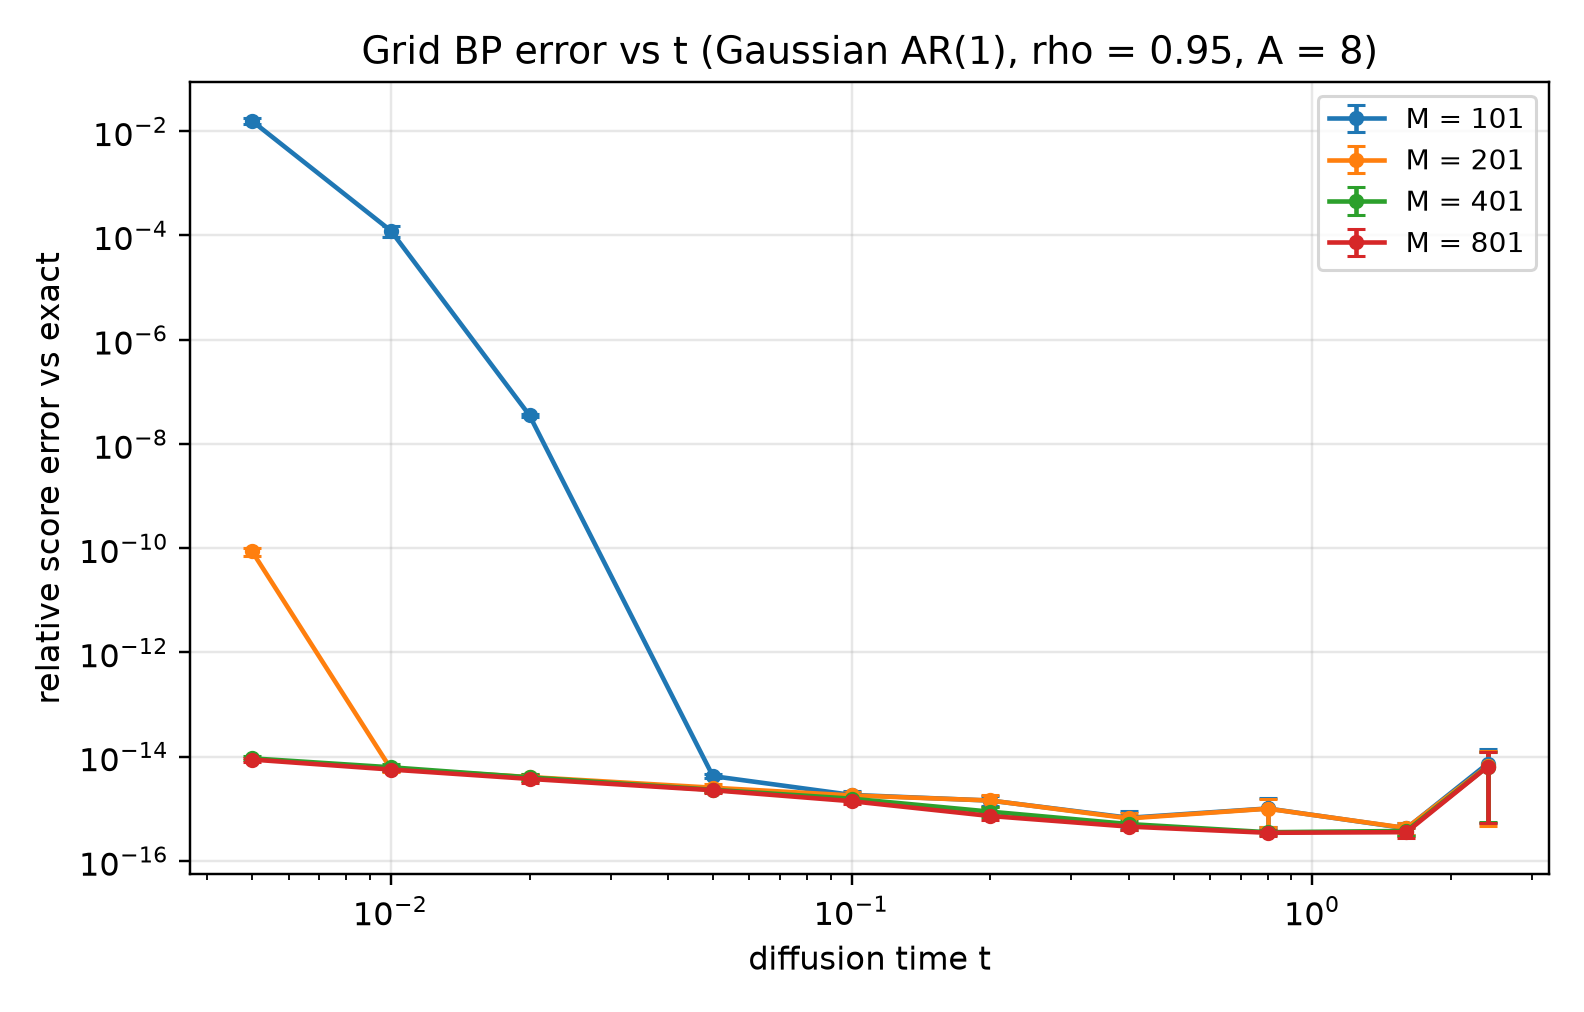

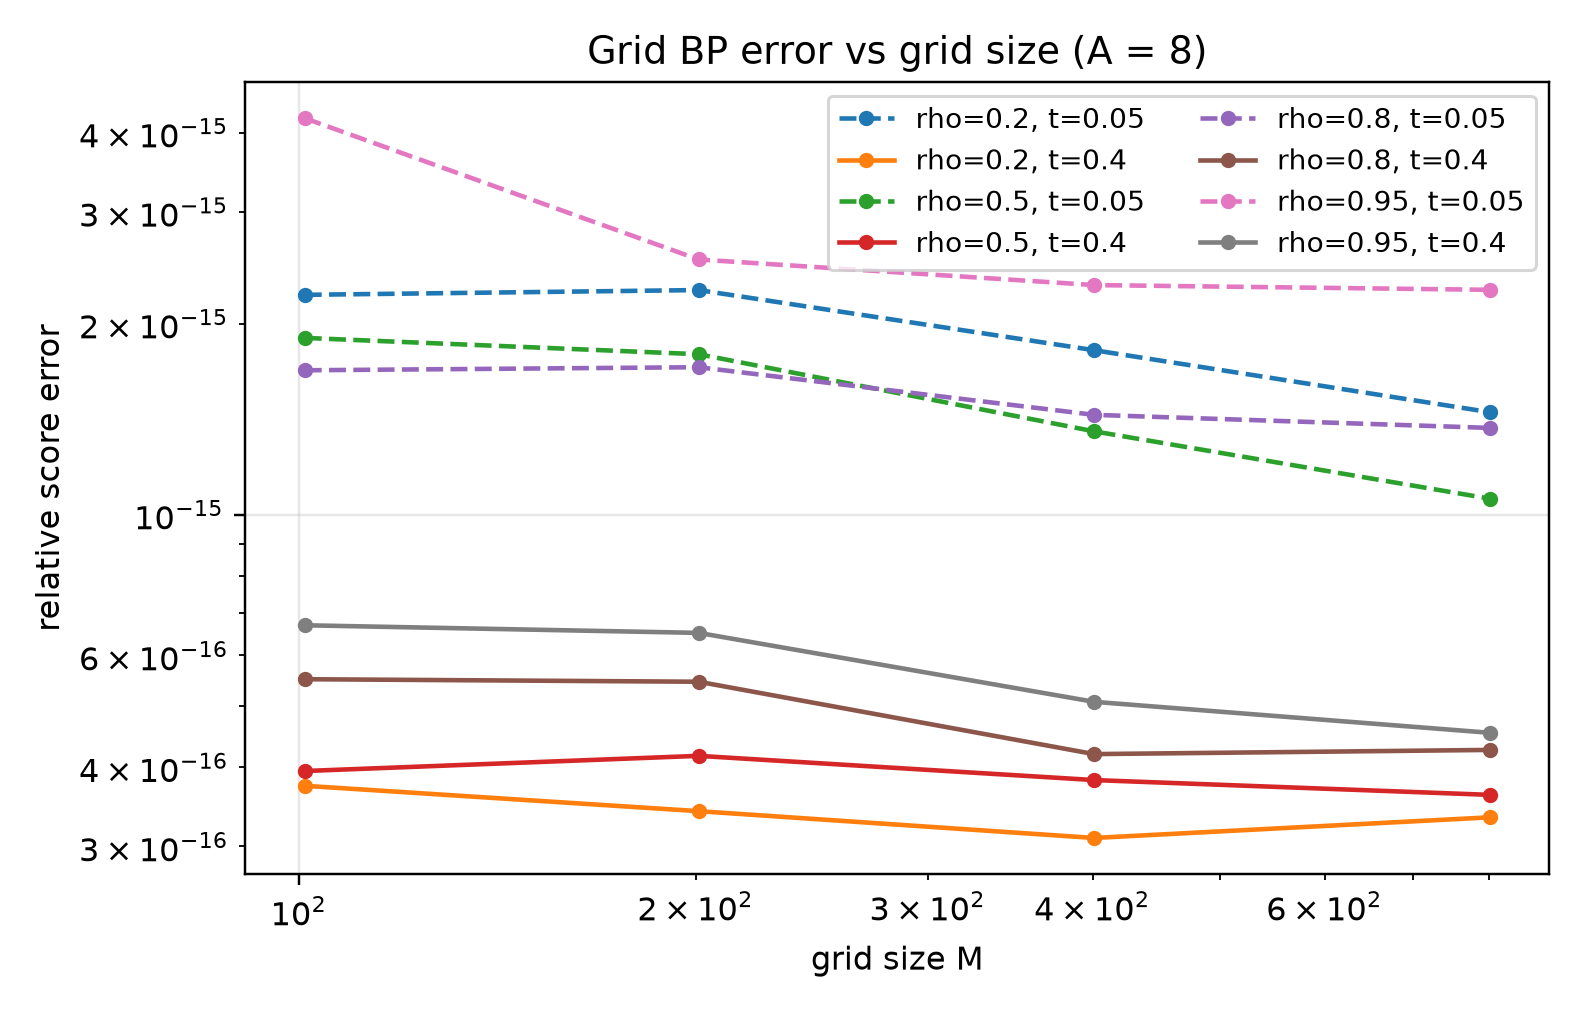

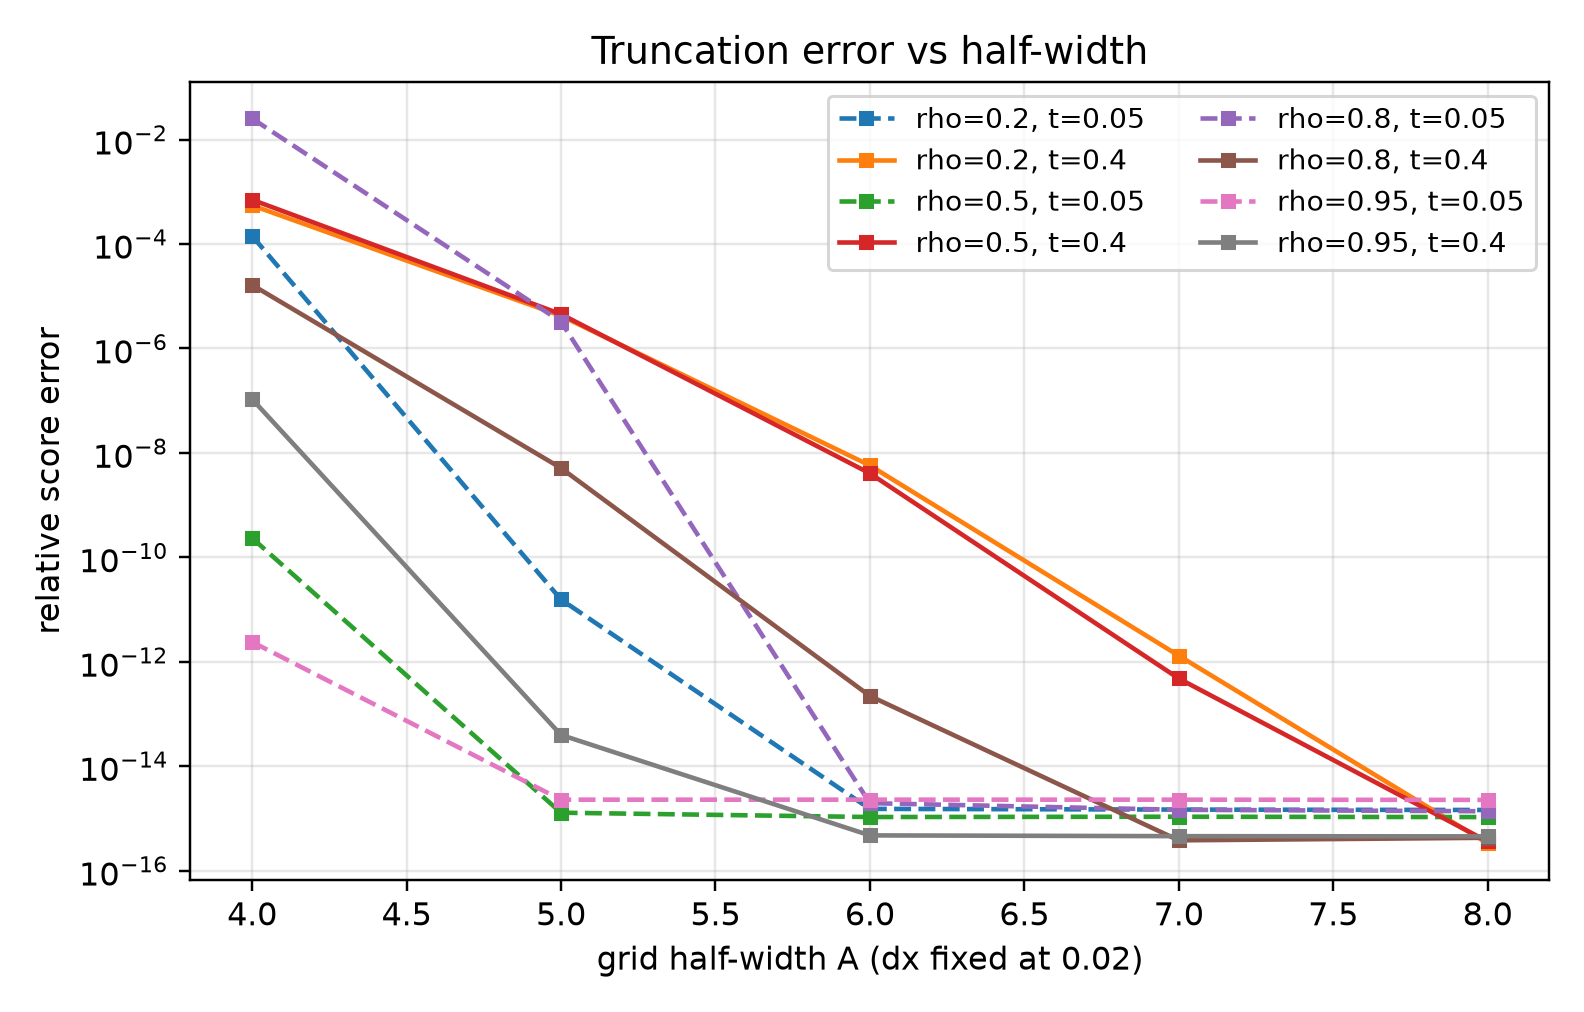

In [3]:
show("grid_error_vs_t.png", "grid_error_vs_M.png", "grid_error_vs_A.png", exp=exp)

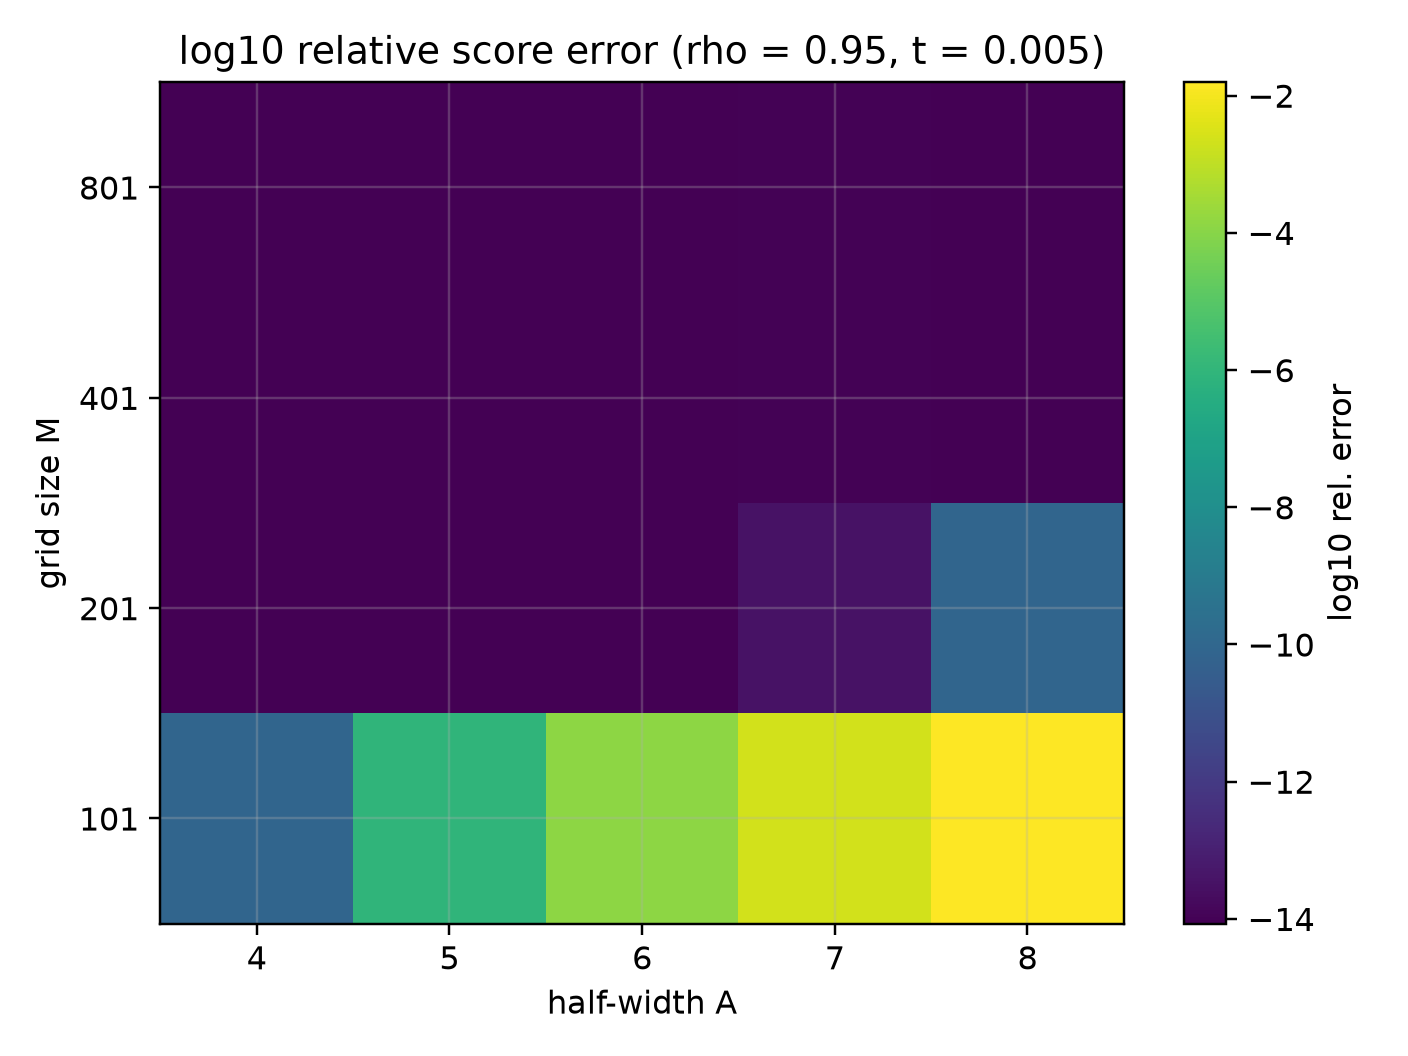

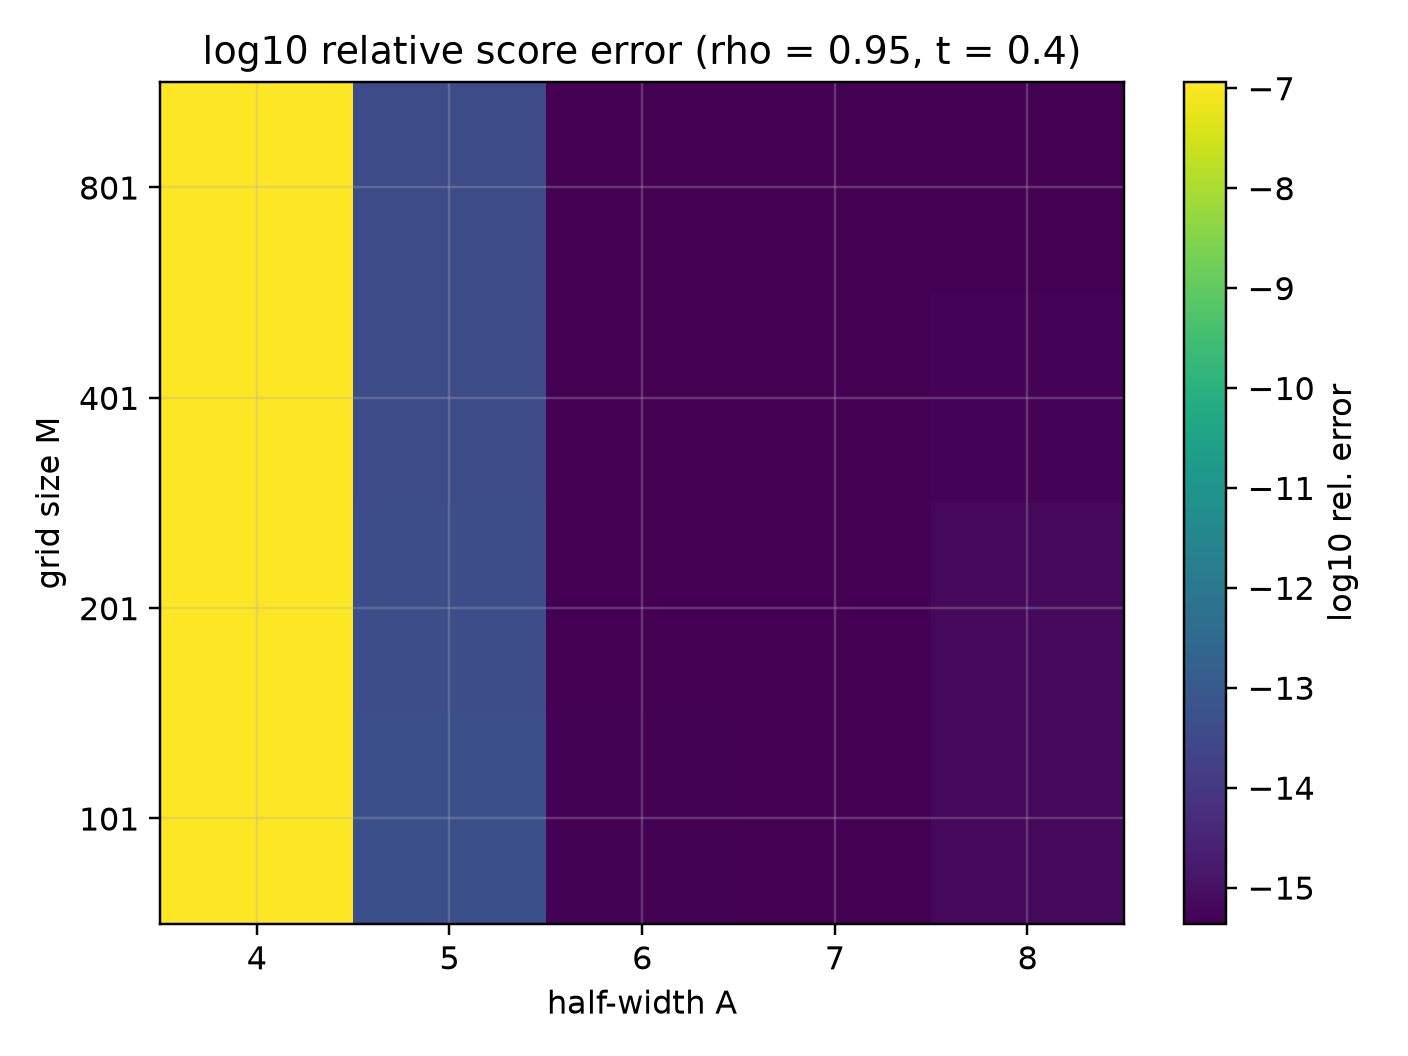

In [4]:
show("grid_heatmap_t0.005.png", "grid_heatmap_t0.4.png", exp=exp)

In [5]:
print((OUT / exp / "RECOMMENDATION.md").read_text())

# Grid parameter recommendation (from exp_01 heatmap, rho = 0.95)

M =  101, A = 4: worst rel. error = 1.144e-07
M =  101, A = 5: worst rel. error = 8.828e-07
M =  101, A = 6: worst rel. error = 1.266e-04
M =  101, A = 7: worst rel. error = 2.398e-03
M =  101, A = 8: worst rel. error = 1.565e-02
M =  201, A = 4: worst rel. error = 1.084e-07
M =  201, A = 5: worst rel. error = 4.169e-14
M =  201, A = 6: worst rel. error = 8.975e-15
M =  201, A = 7: worst rel. error = 3.468e-14
M =  201, A = 8: worst rel. error = 8.626e-11
M =  401, A = 4: worst rel. error = 1.069e-07
M =  401, A = 5: worst rel. error = 3.990e-14
M =  401, A = 6: worst rel. error = 8.526e-15
M =  401, A = 7: worst rel. error = 9.677e-15
M =  401, A = 8: worst rel. error = 9.237e-15
M =  801, A = 4: worst rel. error = 1.066e-07
M =  801, A = 5: worst rel. error = 3.944e-14
M =  801, A = 6: worst rel. error = 8.730e-15
M =  801, A = 7: worst rel. error = 9.934e-15
M =  801, A = 8: worst rel. error = 8.762e-15

Cheapest con